In [136]:
%matplotlib inline

%load_ext autoreload
%autoreload 2

from hubble_fit import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [93]:

# Load Pantheon+ SN metadata
print("Loading Pantheon+ supernova data...")
df_pantheon = pd.read_csv(
    #"https://raw.githubusercontent.com/PantheonPlusSH0ES/DataRelease/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES.dat",
    "data/Pantheon+SH0ES.dat",
    sep=r"\s+"
)

print("Loading SN covariance matrix...")
n_sn = len(df_pantheon)

# Load .cov file with NumPy, skipping the first line (which contains just "1701")
cov_flat = np.loadtxt(
    #"https://raw.githubusercontent.com/PantheonPlusSH0ES/DataRelease/main/Pantheon%2B_Data/4_DISTANCES_AND_COVAR/Pantheon%2BSH0ES_STAT%2BSYS.cov",
    "data/Pantheon+SH0ES_STAT+SYS.cov",
    skiprows=1
)

# Reshape into square matrix
cov_matrix = cov_flat.reshape((n_sn, n_sn))

# Confirm shape is correct
assert cov_matrix.shape == (n_sn, n_sn), f"Expected ({n_sn},{n_sn}), got {cov_matrix.shape}"

# Invert covariance and pre-compute log-determinant for SN likelihood
global Cov_inv, logdetCov
Cov_inv = np.linalg.inv(cov_matrix)
sign, logdet = np.linalg.slogdet(cov_matrix)
if sign <= 0:
    raise ValueError("Covariance matrix is not positive-definite!")
logdetCov = logdet
print("Data loaded. Running joint cosmographic fits...")


Loading Pantheon+ supernova data...
Loading SN covariance matrix...
Data loaded. Running joint cosmographic fits...


In [94]:
print("Loading quasar data...")
#df_agn = load_quasar_data("data/may23_all_merged.h5")
#df_agn = load_quasar_data("data/N20_w500_grace/may21_joint_fits_N20_N40_merged.h5")
df_agn = load_quasar_data("data/may23_all_merged.h5", populate_sdss=True)
#df_agn_f = df_agn.sample(n=100, random_state=42).reset_index(drop=True)

Loading quasar data...


Reading quasars from HDF5: 100%|██████████| 3202/3202 [00:14<00:00, 216.88it/s]

Number of quasars loaded: 3202
Populating SDSS fields...
Populating SDSS fields: 3202



Populating SDSS fields: 100%|██████████| 3202/3202 [04:31<00:00, 11.80it/s]

Writing 3202 quasars to data/may23_all_merged.h5


Columns with NaNs: ['X', 'band_idx', 'y', 'yerr', 'bestP']
Number of quasars with 0 < z <= 1: 684
Number of quasars with z > 3: 81
Final number of quasars: 3150


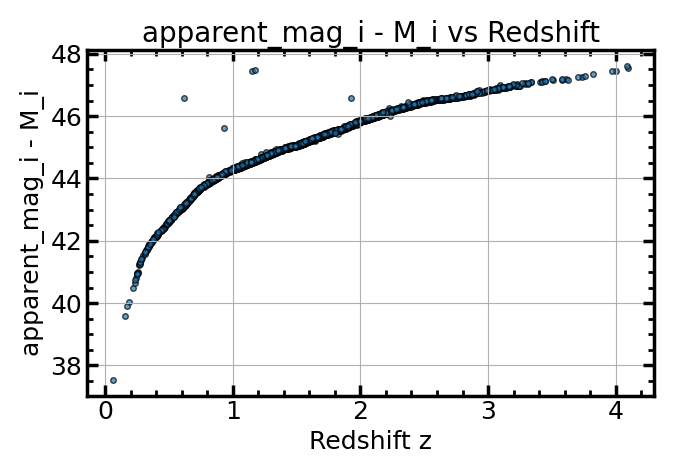

In [125]:
plt.figure(figsize=(7, 5))
plt.scatter(df_agn['z'], df_agn['apparent_mag_i'] - df_agn['M_i'], alpha=0.7, edgecolor='k')
plt.xlabel('Redshift z')
plt.ylabel('apparent_mag_i - M_i')
plt.title('apparent_mag_i - M_i vs Redshift')
plt.grid(True)
plt.tight_layout()
plt.show()

Log sigma hat pivot: -2.076


100%|██████████| 10/10 [00:25<00:00,  2.56s/it]
/Users/colinburke/miniforge3/lib/python3.12/site-packages/emcee/autocorr.py:38: RuntimeWarning: invalid value encountered in divide
  acf /= acf[0]


Autocorr time: [nan nan nan nan nan nan nan nan nan nan nan nan]
Applying completeness correction in hubble diagram...


<string>:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


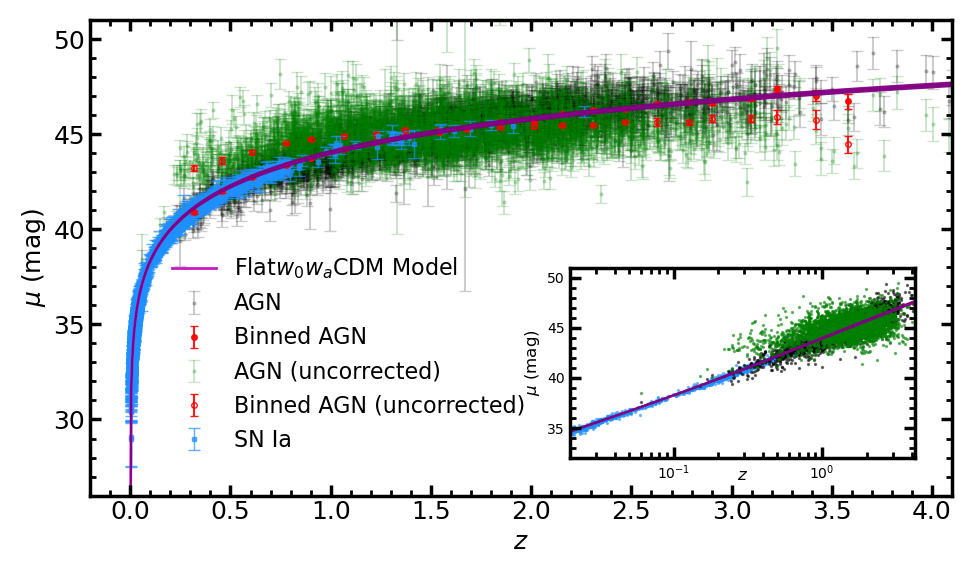

In [137]:
cosmo_model = 'Flatw0waCDM'
sampler_joint, _, mag_corr, logZ, logZerr = run_mcmc_pipeline(df_agn, df_pantheon, cosmo_model=cosmo_model, only_sna=False,
                                            completeness=True, use_full_cov=False, num_warmup=20, num_samples=10)

df_agn['apparent_mag_i_corr'] = mag_corr

from hubble_plotting import plot_hubble
residuals, mu_pred_std = plot_hubble(sampler_joint, df_agn, df_pantheon, cosmo_model=cosmo_model, show=True, completeness=True, show_uncorrected=True)

### Visualize completeness weights in likelihood

In [138]:
# Get the flat samples from the sampler
flat_samples = sampler_joint.get_chain(discard=0, thin=1, flat=True)
median_theta = np.median(flat_samples, axis=0)

completeness_params = get_completeness_function_2d(df_agn) if completeness else None
log_sigma_hat_pivot = df_agn['log_sigma_hat_UV'].mean()

# Evaluate log_likelihood at the median parameters
ll, norm_correction, m_model = log_likelihood(
    median_theta, cosmo_model,
    df_agn, df_pantheon, completeness_params, log_sigma_hat_pivot,
    only_sna=False, use_full_cov=False,
    return_params=True
)

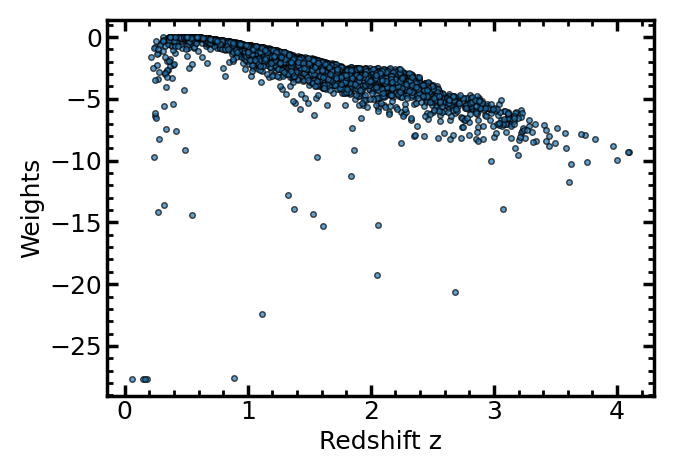

In [139]:
plt.figure(figsize=(7, 5))
plt.scatter(df_agn['z'], np.full_like(df_agn['z'], norm_correction), alpha=0.7, edgecolor='k')
plt.xlabel('Redshift z')
plt.ylabel('Weights')
plt.grid(False)
plt.tight_layout()
plt.show()

Applying completeness correction in hubble diagram...


<string>:87: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


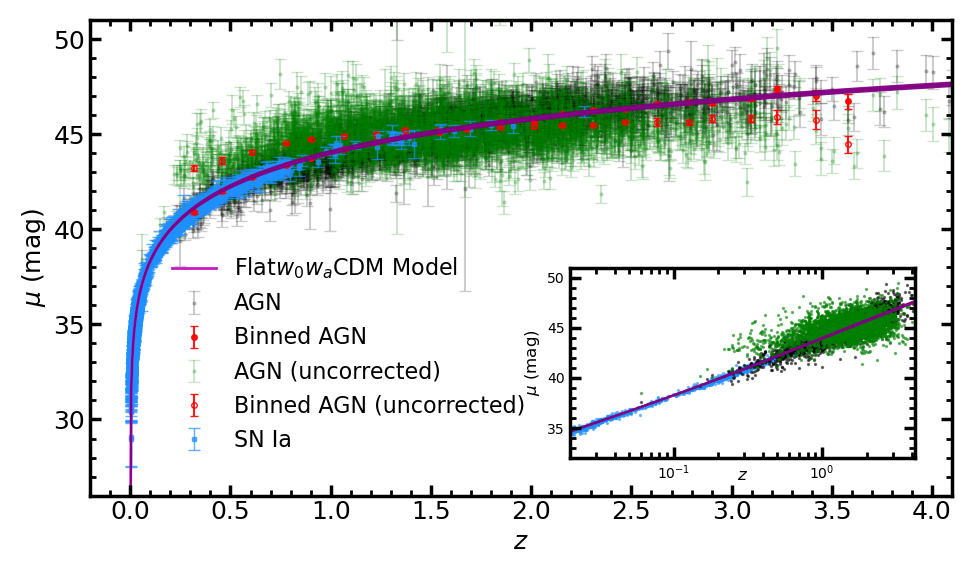

In [140]:
residuals, mu_pred_std = plot_hubble(sampler_joint, df_agn, df_pantheon, cosmo_model=cosmo_model,
        show=True, completeness=True, show_true=False, show_uncorrected=True)

Intercepts: [49.89872624 54.45195267 52.7380818  ... 54.4230015  51.72370039
 57.18570386]


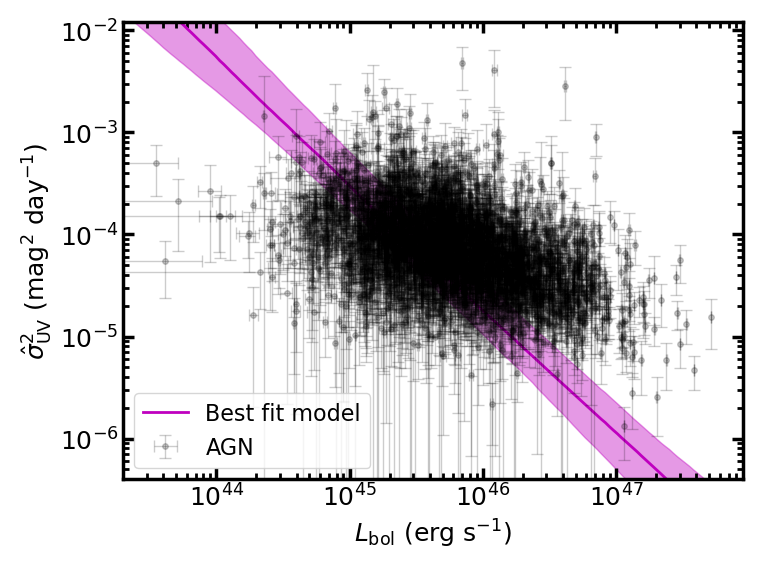

(array([-1.1865384 , -1.25601655, -1.23569097, ..., -1.28587414,
        -1.23028355, -1.34906647]),
 array([49.89872624, 54.45195267, 52.7380818 , ..., 54.4230015 ,
        51.72370039, 57.18570386]))

In [141]:
from hubble_plotting import plot_predicted_sigma_hat_vs_luminosity
plot_predicted_sigma_hat_vs_luminosity(sampler_joint, df_agn, cosmo_model, show=True)

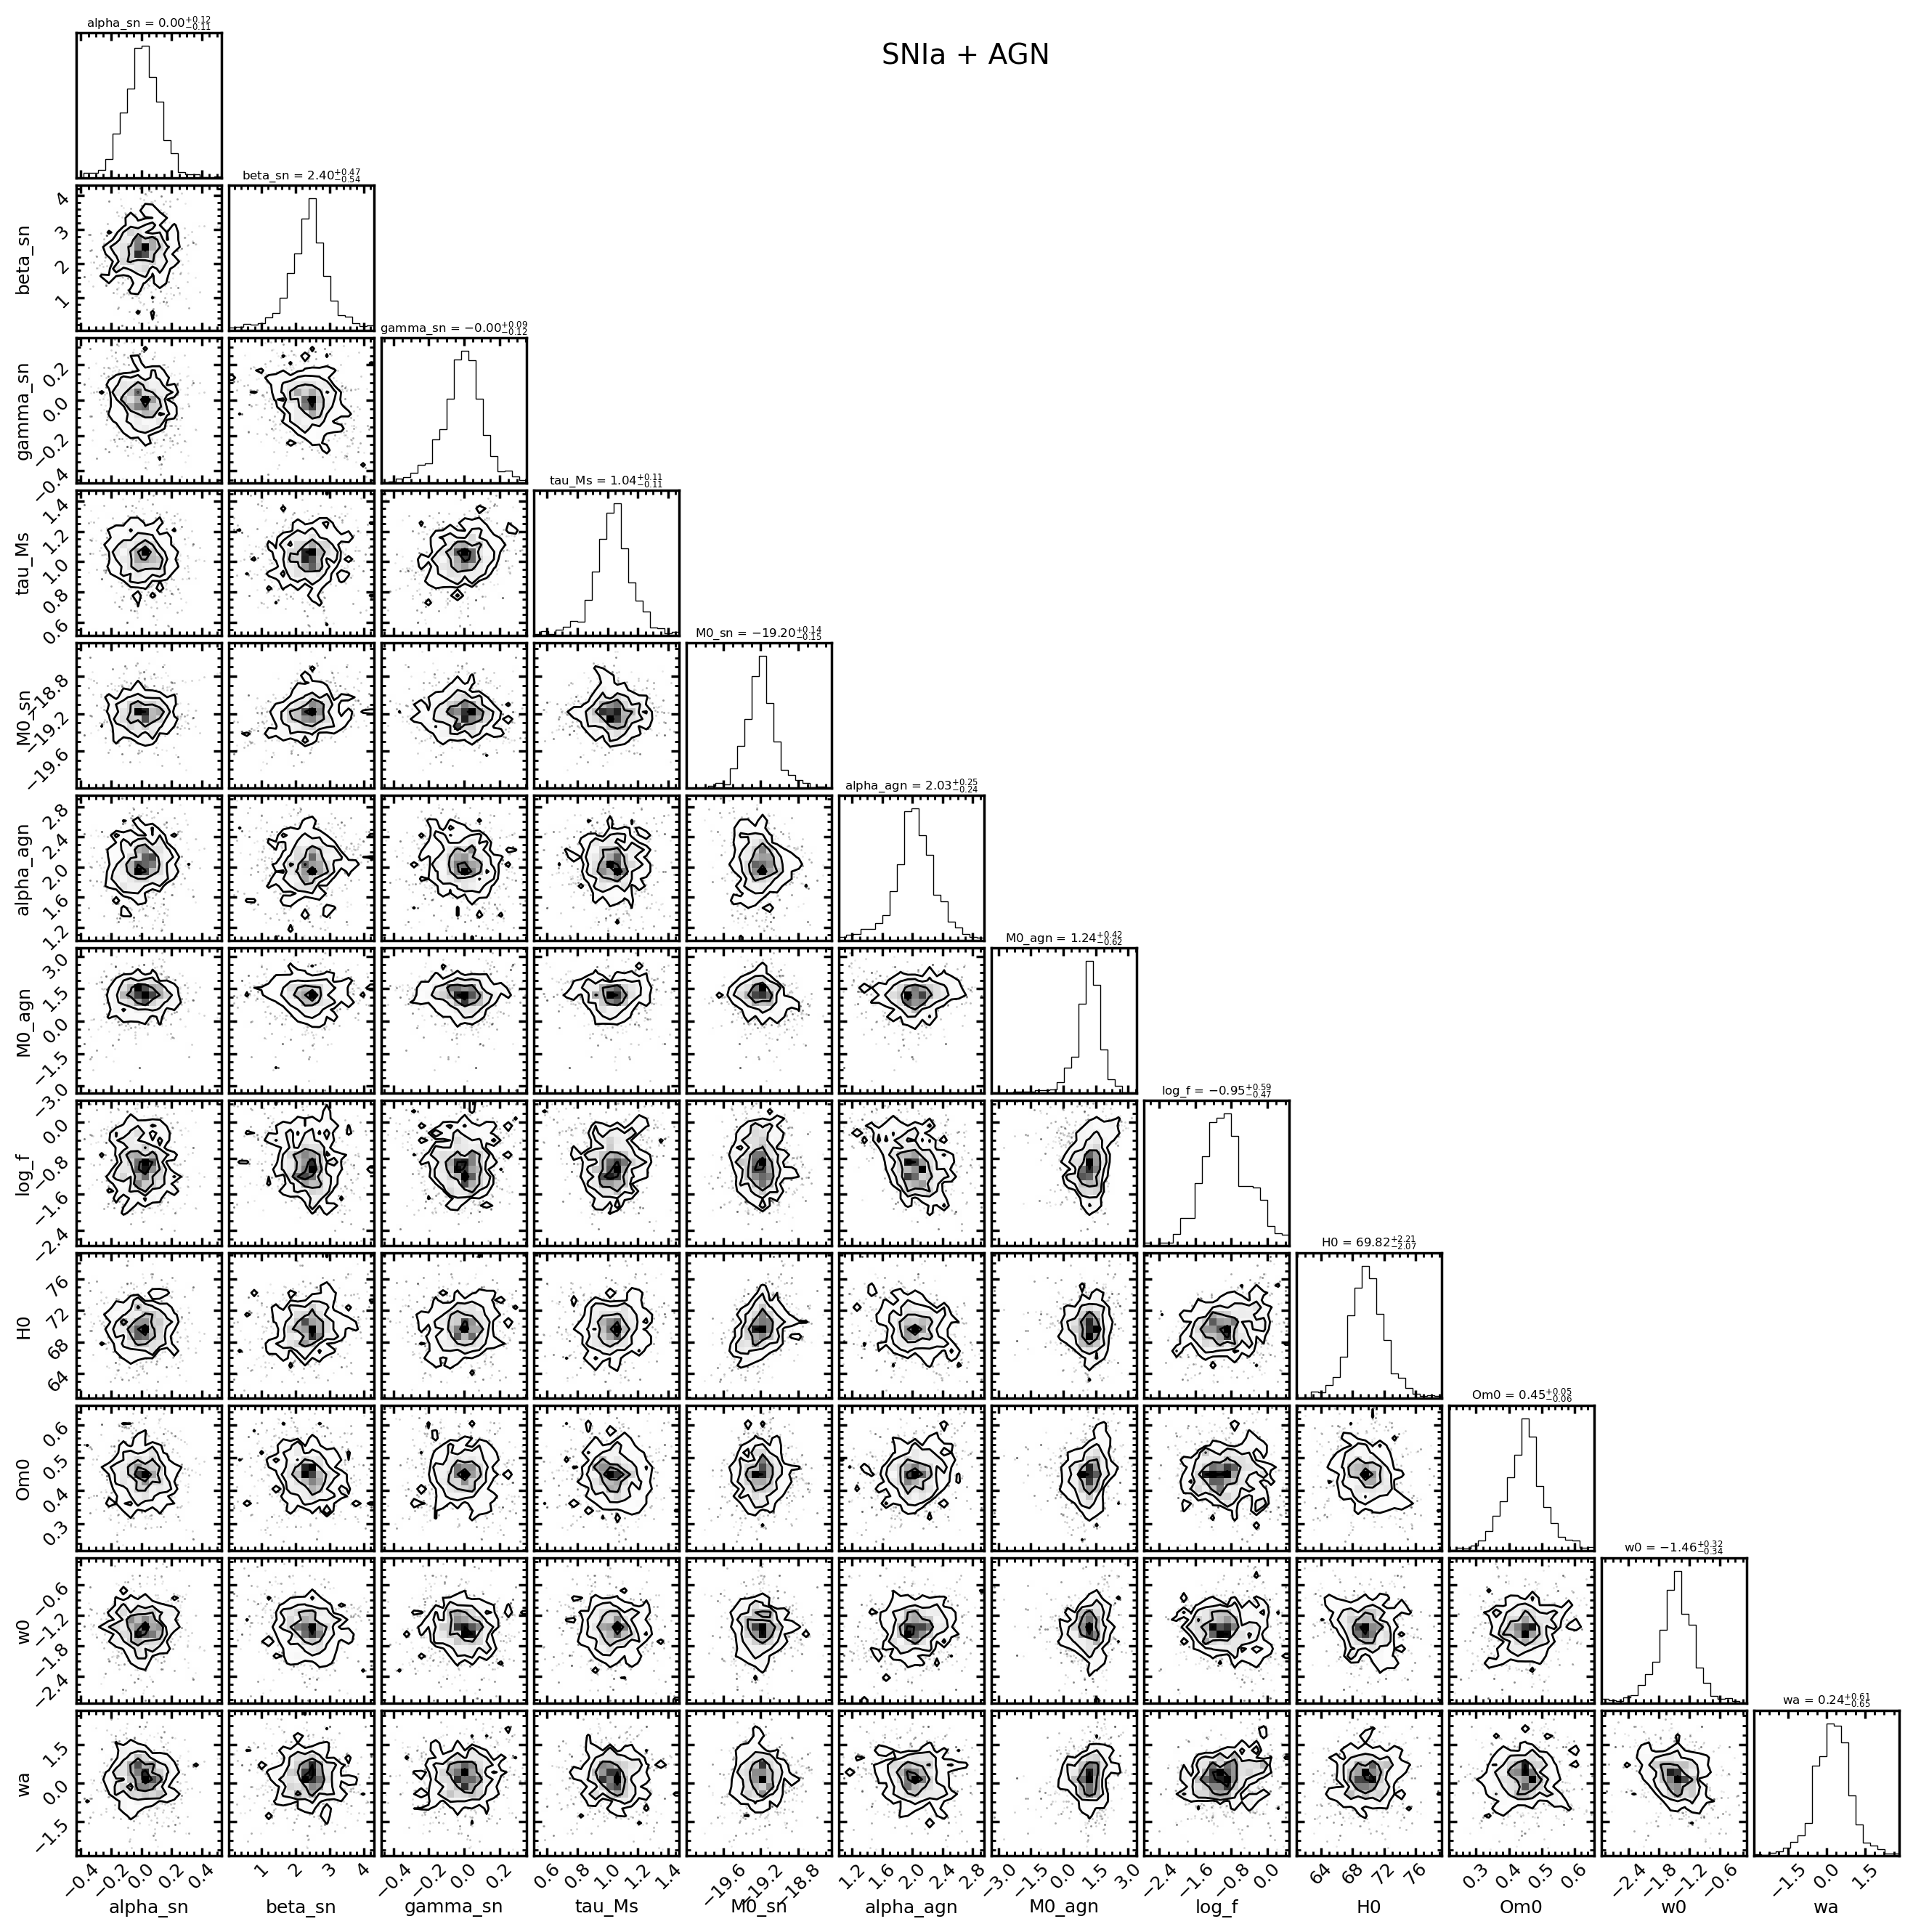

In [142]:
from hubble_plotting import plot_posterior_corner
plot_posterior_corner(sampler_joint, cosmo_model=cosmo_model, show=True)

M_i_pred [-23.7504084  -23.94036054 -25.24034451 ... -23.78050525 -25.26614984
 -24.86211594]
M0_AGN 0.33902460952132385
alpha_AGN 1.8546977447656712
[-23.7504084  -23.94036054 -25.24034451 ... -23.78050525 -25.26614984
 -24.86211594]


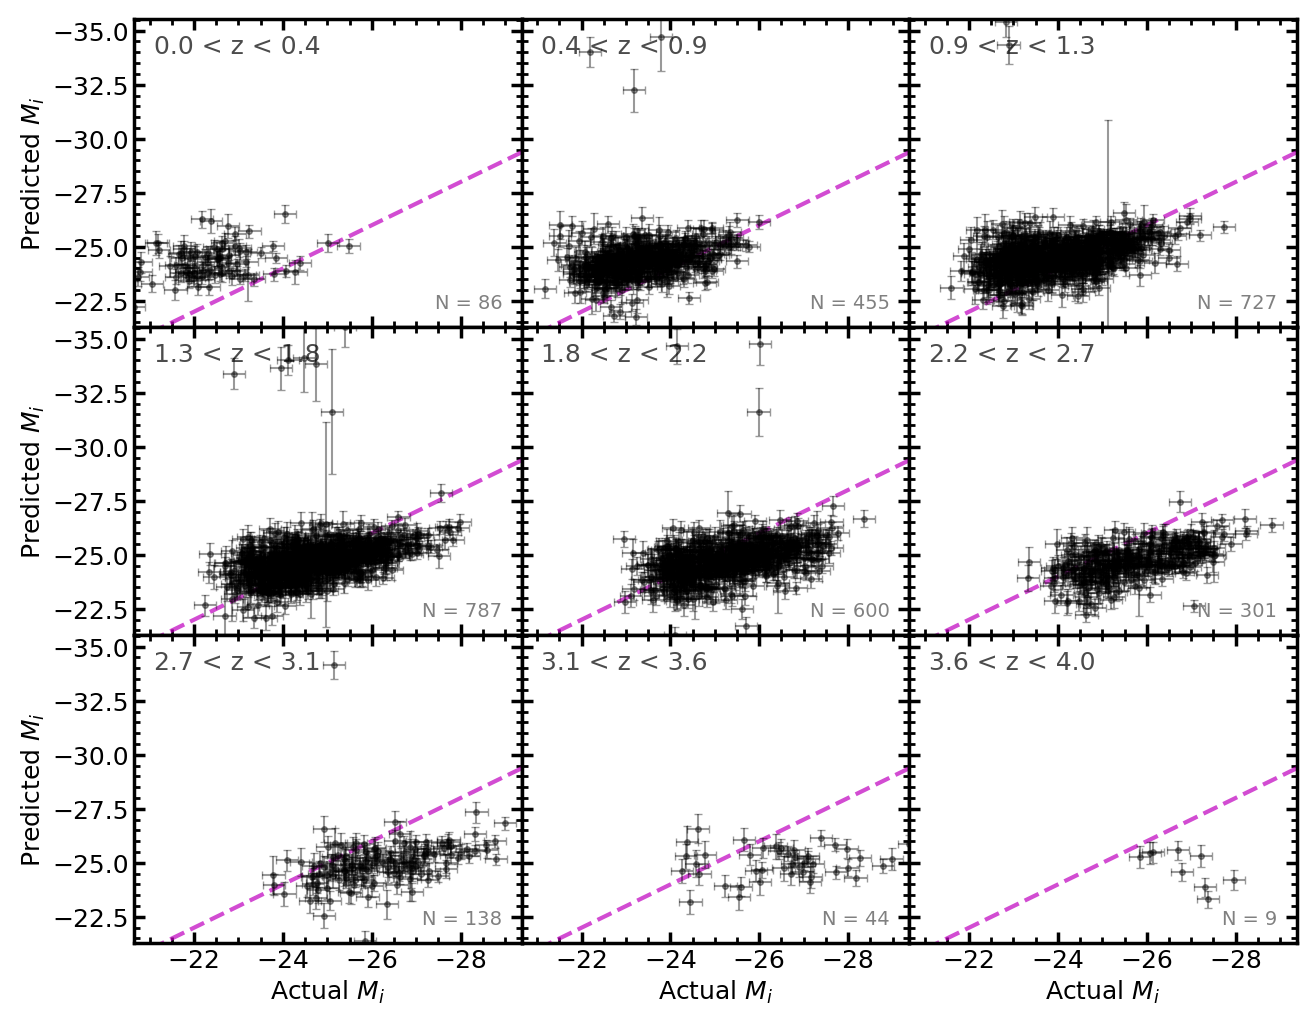

In [29]:
from hubble_plotting import plot_predicted_vs_actual_Mi
plot_predicted_vs_actual_Mi(sampler_joint, df_agn, cosmo_model=cosmo_model, show=True)

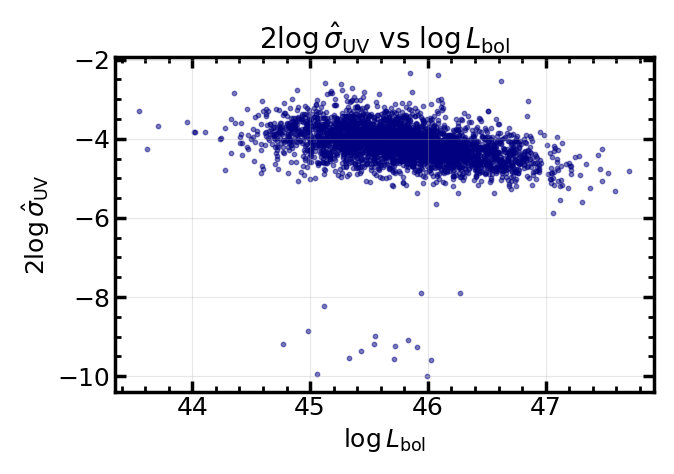

In [96]:
from hubble_plotting import plot_sigma_hat_vs_log_lbol
plot_sigma_hat_vs_log_lbol(df_agn, show=True)
# now

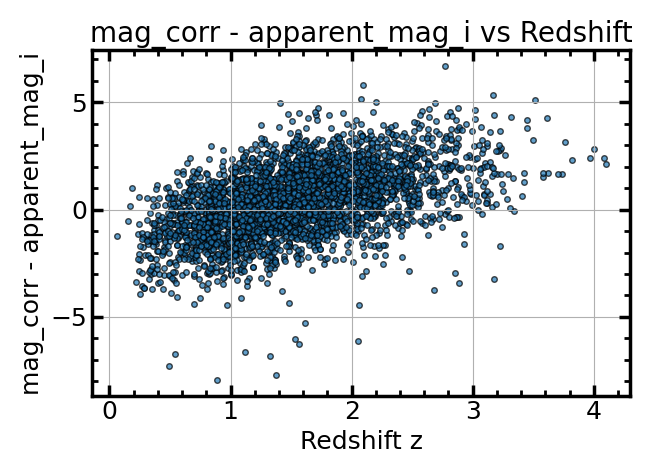

In [43]:
plt.figure(figsize=(7, 5))
plt.scatter(df_agn['z'], mag_corr - df_agn['apparent_mag_i'], alpha=0.7, edgecolor='k')
plt.xlabel('Redshift z')
plt.ylabel('mag_corr - apparent_mag_i')
plt.title('mag_corr - apparent_mag_i vs Redshift')
plt.grid(True)
plt.tight_layout()
plt.show()

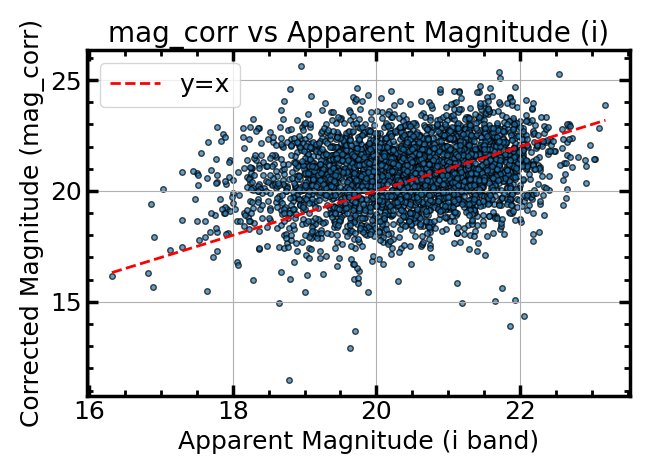

In [44]:
plt.figure(figsize=(7, 5))
plt.scatter(df_agn['apparent_mag_i'], mag_corr, alpha=0.7, edgecolor='k')
plt.xlabel('Apparent Magnitude (i band)')
plt.ylabel('Corrected Magnitude (mag_corr)')
plt.title('mag_corr vs Apparent Magnitude (i)')
plt.plot([df_agn['apparent_mag_i'].min(), df_agn['apparent_mag_i'].max()],
         [df_agn['apparent_mag_i'].min(), df_agn['apparent_mag_i'].max()],
         color='red', linestyle='--', label='y=x')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [7]:
import pickle

with open("sampler_joint_notdz2.pkl", "wb") as f:
    pickle.dump(sampler_joint, f)

In [10]:
# compute delta mag correction
#from hubble_plotting import compute_per_object_delta_mag
#from scipy.interpolate import interp1d
#completeness_params = get_completeness_function_simple(20)
#p_detect, mag_eval, dm = completeness_params

# flat_samples = sampler.get_chain(discard=0, thin=1, flat=True)
# median_theta = np.median(flat_samples, axis=0)

# ll, norm_correction, m_model = log_likelihood(
#     median_theta, cosmo_model,
#     df_agn, df_pantheon, completeness_params,
#     only_sna=False, use_full_cov=False,
#     return_params=True
# )
# delta_mag_arr = apply_delta_mag_correction(df_agn, mu_pred_median, df_agn['z'], norm_correction, p_detect, n_bins=8)
#p_detect_interp = interp1d(mag_eval, p_detect, bounds_error=False, fill_value=0.0)

#delta_mag_arr = compute_per_object_delta_mag(df_agn, p_detect_interp, delta_m=0.01)

from hubble_utils import compute_delta_mag_bias, compute_delta_mag_bias_2d
#delta_mag_arr = compute_delta_mag_bias_2d(df_agn['apparent_mag_i'], 20)
# First, get completeness function and related parameters

completeness2d, mag_centers, z_centers, dm, dz = get_completeness_function_2d(df_agn)
# Then compute delta mag bias correction
delta_mag_arr = compute_delta_mag_bias_2d(df_agn, completeness2d, mag_centers, z_centers, dm)


plt.figure(figsize=(7, 5))
#delta_mag_arr = delta_mag_arr[delta_mag_arr < 1000]
plt.hist(delta_mag_arr[~np.isnan(delta_mag_arr) & np.isfinite(delta_mag_arr)], bins=30, color='skyblue', edgecolor='k', alpha=0.7)
plt.xlabel('Delta Mag Correction')
plt.ylabel('Count')
plt.title('Histogram of Delta Mag Correction')
plt.grid(True)
plt.yscale('log')
plt.tight_layout()
plt.show()

ImportError: cannot import name 'compute_delta_mag_bias_2d' from 'hubble_utils' (/home/dutra/dev/eztaox/tutorials/hubble_utils.py)

In [13]:
from scipy.stats import linregress
from hubble_utils import get_completeness_function_2d, compute_delta_mag_bias_2d_zbins

completeness2d, mag_centers, z_centers, dm, dz = get_completeness_function_2d(df_agn)
delta_mag_arr, _ = compute_delta_mag_bias_2d_zbins(df_agn, completeness2d, mag_centers, z_centers, dm)

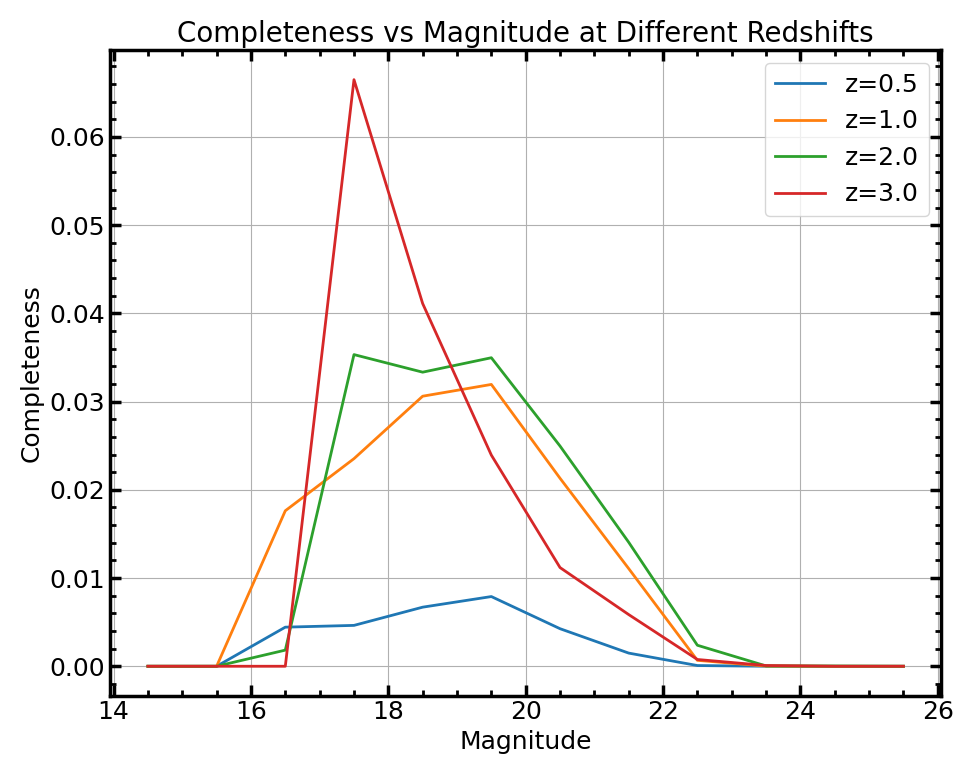

In [14]:
z_vals_to_test = [0.5, 1.0, 2.0, 3.0]
plt.figure()
for zval in z_vals_to_test:
    plt.plot(mag_centers, completeness2d(mag_centers, zval*np.ones_like(mag_centers)), label=f'z={zval}')
plt.xlabel('Magnitude')
plt.ylabel('Completeness')
plt.title('Completeness vs Magnitude at Different Redshifts')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [47]:
df_agn[df_agn['z']>3.5]['apparent_mag_i']

86     21.493103
119    19.802795
121    21.177982
195    20.469383
265    19.852093
345    20.222942
Name: apparent_mag_i, dtype: float32

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


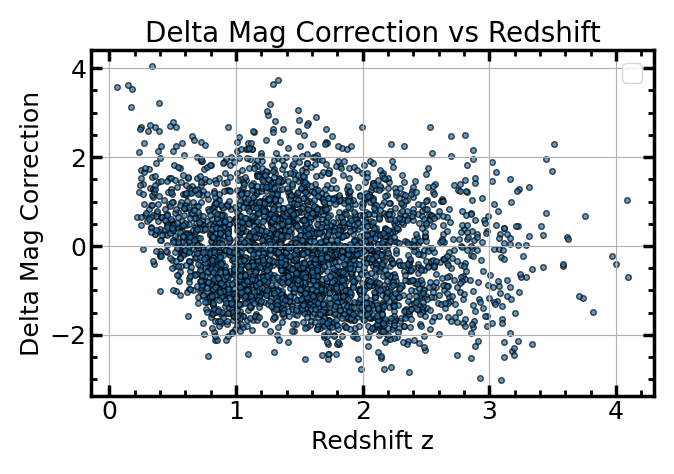

In [32]:

from hubble_utils import get_completeness_function_2d, compute_delta_mag_bias_2d_zbins

completeness2d, mag_centers, z_centers, dm, dz = get_completeness_function_2d(df_agn)
delta_mag_arr, _ = compute_delta_mag_bias_2d_zbins(df_agn, completeness2d, mag_centers, z_centers, dm)

plt.figure(figsize=(7, 5))
mask = np.isfinite(df_agn['z']) & np.isfinite(delta_mag_arr)
plt.legend()
plt.scatter(df_agn['z'], delta_mag_arr, alpha=0.7, edgecolor='k')
plt.xlabel('Redshift z')
plt.ylabel('Delta Mag Correction')
plt.title('Delta Mag Correction vs Redshift')
plt.grid(True)
plt.tight_layout()
plt.show()



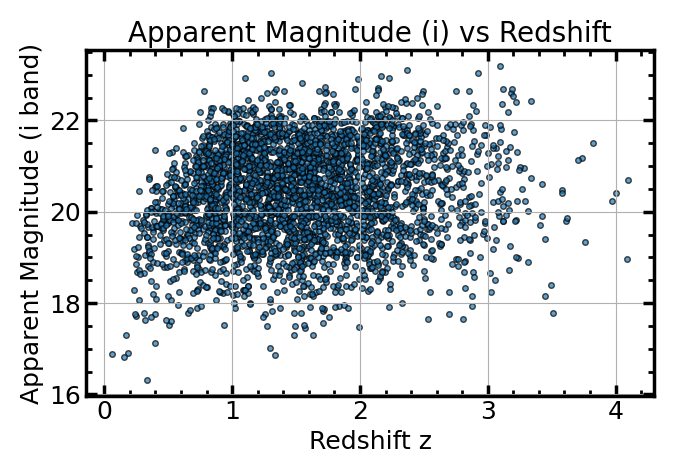

In [33]:
plt.figure(figsize=(7, 5))
plt.scatter(df_agn['z'], df_agn['apparent_mag_i'], alpha=0.7, edgecolor='k')
plt.xlabel('Redshift z')
plt.ylabel('Apparent Magnitude (i band)')
plt.title('Apparent Magnitude (i) vs Redshift')
plt.grid(True)
plt.tight_layout()
plt.show()

In [34]:
from matplotlib.colors import LogNorm

plt.figure(figsize=(8, 6))
im = plt.imshow(
    p_grid,
    extent=[mag_grid[0], mag_grid[-1], z_grid[0], z_grid[-1]],
    aspect='auto',
    origin='lower',
    cmap='viridis',
    norm=LogNorm(vmin=np.nanmin(p_grid[p_grid > 0]), vmax=np.nanmax(p_grid))
)
plt.colorbar(im, label='Completeness $p_{\\rm detect}$')
plt.xlabel('Apparent Magnitude')
plt.ylabel('Redshift z')
plt.title('Completeness $p_{\\rm detect}$(mag, z)')
plt.tight_layout()
plt.show()


NameError: name 'p_grid' is not defined

<Figure size 800x600 with 0 Axes>

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def plot_p_detect_for_all_agns(df_agn, p_detect, mag_range=None, n_mag=200, cmap='viridis'):
    mags_agn = df_agn['apparent_mag_i'].values
    zs_agn = df_agn['z'].values

    if mag_range is None:
        min_mag = np.min(mags_agn) - 1
        max_mag = np.max(mags_agn) + 1
    else:
        min_mag, max_mag = mag_range

    mag_grid = np.linspace(min_mag, max_mag, n_mag)
    norm = plt.Normalize(np.min(zs_agn), np.max(zs_agn))
    cmap = plt.get_cmap(cmap)

    fig, ax = plt.subplots(figsize=(7, 5))
    for mag_i, z_i in zip(mags_agn, zs_agn):
        z_arr = np.full_like(mag_grid, z_i, dtype=float)
        p_vals = p_detect(mag_grid, z_arr)
        ax.plot(mag_grid, p_vals, color=cmap(norm(z_i)), alpha=0.5, lw=1)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, label='Redshift z')
    ax.set_xlabel('Apparent Magnitude')
    ax.set_ylabel('Completeness $p_{\\rm detect}$')
    ax.set_title('Completeness Function $p_{\\rm detect}$(mag, z) for All AGNs')
    fig.tight_layout()
    plt.show()

plot_p_detect_for_all_agns(df_agn, p_detect)


NameError: name 'p_detect' is not defined

Generating corner plot: 100%|██████████| 4/4 [00:22<00:00,  5.51s/it]


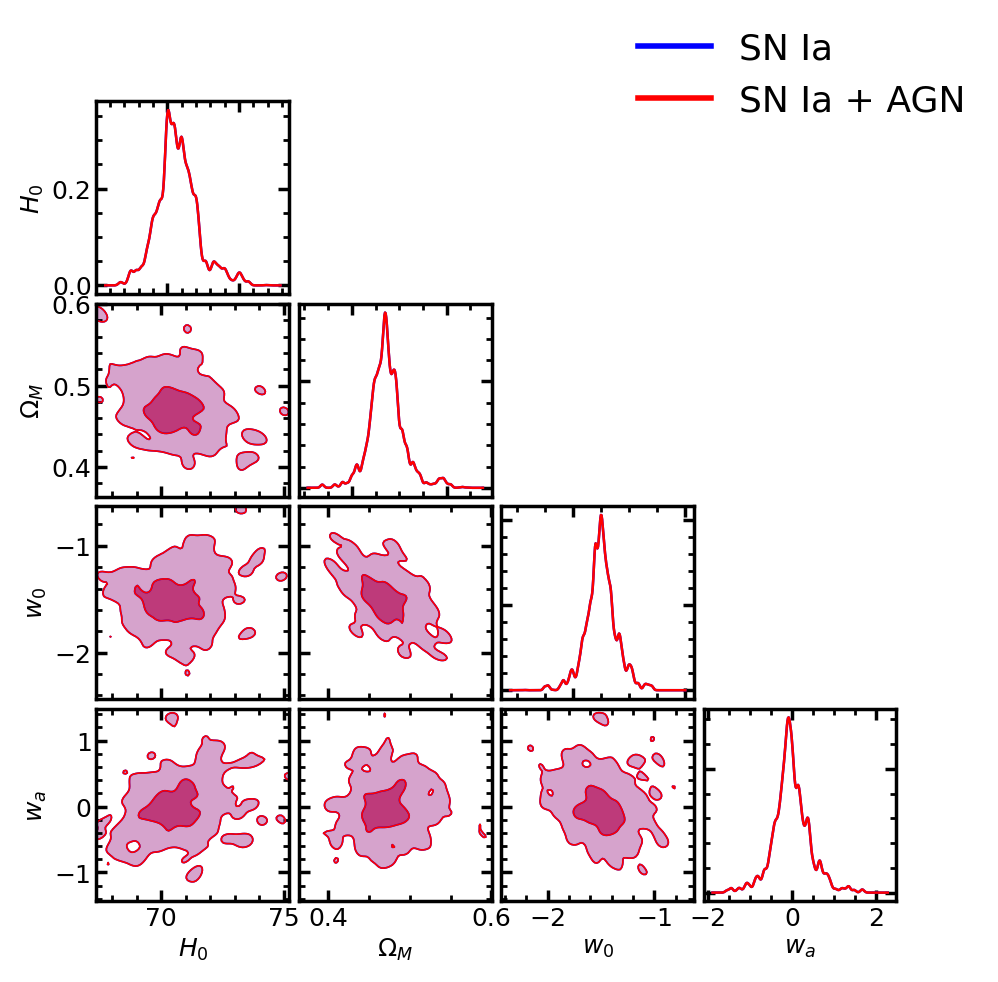

In [6]:
plot_cosmo_corner(sampler_joint, sampler_joint, cosmo_model=cosmo_model, show=True)

Intercepts: [61.28479726 58.4242189  50.14911432 ... 65.57260529 63.15472128
 60.21106258]


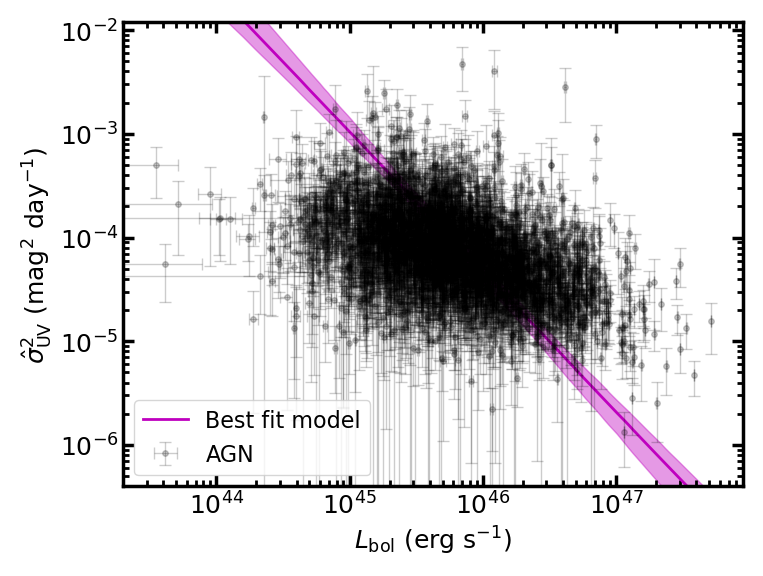

(array([-1.42412309, -1.36445961, -1.18428408, ..., -1.5207874 ,
        -1.46596659, -1.40273184]),
 array([61.28479726, 58.4242189 , 50.14911432, ..., 65.57260529,
        63.15472128, 60.21106258]))

In [35]:
from scipy.stats import linregress

from hubble_plotting import plot_predicted_sigma_hat_vs_luminosity
plot_predicted_sigma_hat_vs_luminosity(sampler_joint, df_agn, cosmo_model=cosmo_model, show=True)
#plot_predicted_vs_actual_loglbol(sampler_joint, df_agn, cosmo_model=cosmo_model, show=True)

In [15]:
quasar_list = read_quasars_from_hdf5("data/may8_lc_all.h5")


Reading quasars from HDF5: 100%|██████████| 38825/38825 [02:20<00:00, 275.41it/s]


In [16]:
df_agn = pd.DataFrame(quasar_list)

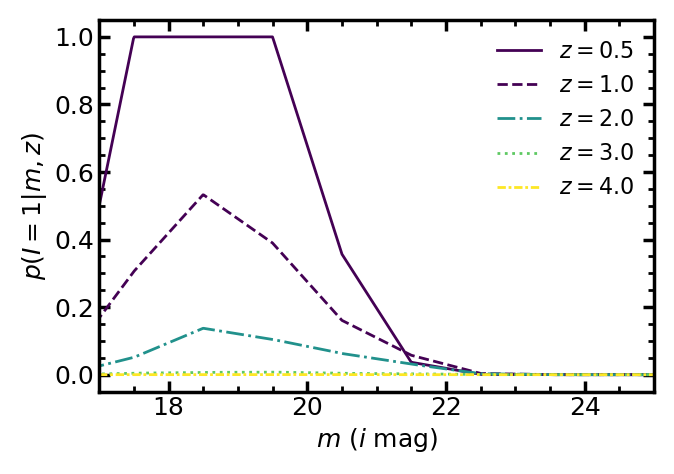

In [36]:
from hubble_utils import *
from hubble_plotting import *

#df_agn = load_quasar_data()
p_detect, mag_centers, z_centers, dm, dz = get_completeness_function_2d(df_agn)
plot_completeness_vs_mag_at_redshifts(p_detect, mag_centers, z_centers, show=True)

In [ ]:
# Estimate the local slope of ln p(m) near the mean magnitude

mean_mag = np.mean(m_model)
# Evaluate p_detect at mean_mag for a typical z
z_typical = np.median(z)
dm = 0.01
p1 = p_detect(mean_mag, z_typical)
p2 = p_detect(mean_mag + dm, z_typical)
alpha = - (np.log(p2) - np.log(p1)) / dm

# Estimate delta mag
N = len(m_model)
delta_mag = -norm_correction / (N * alpha)
print(f"Estimated Δmag from norm_correction: {delta_mag:.3f} mag")

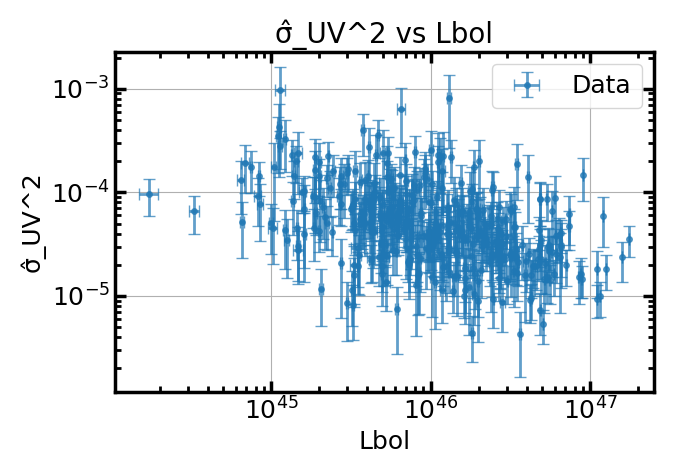

In [66]:
from scipy.stats import linregress

x = 10**df_agn['log_lbol']
y = 10**(2*df_agn['log_sigma_hat_UV'])
yerr = 2 * 10**(2*df_agn['log_sigma_hat_UV']) * df_agn['log_sigma_hat_UV_err'] * np.log(10)
xerr = 10**df_agn['log_lbol'] * df_agn['log_lbol_err'] * np.log(10)

slope, intercept, r_value, p_value, std_err = linregress(x, y)

plt.figure(figsize=(7, 5))
plt.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='o', alpha=0.7, label='Data')
#plt.plot(x, slope * x + intercept, color='red', label=f'Fit: y={slope:.2f}x+{intercept:.2f}')
plt.xlabel('Lbol')
plt.ylabel('σ̂_UV^2')
plt.title('σ̂_UV^2 vs Lbol')
plt.grid(True)
plt.legend()
plt.xscale('log')
plt.yscale('log')   
plt.tight_layout()
plt.show()


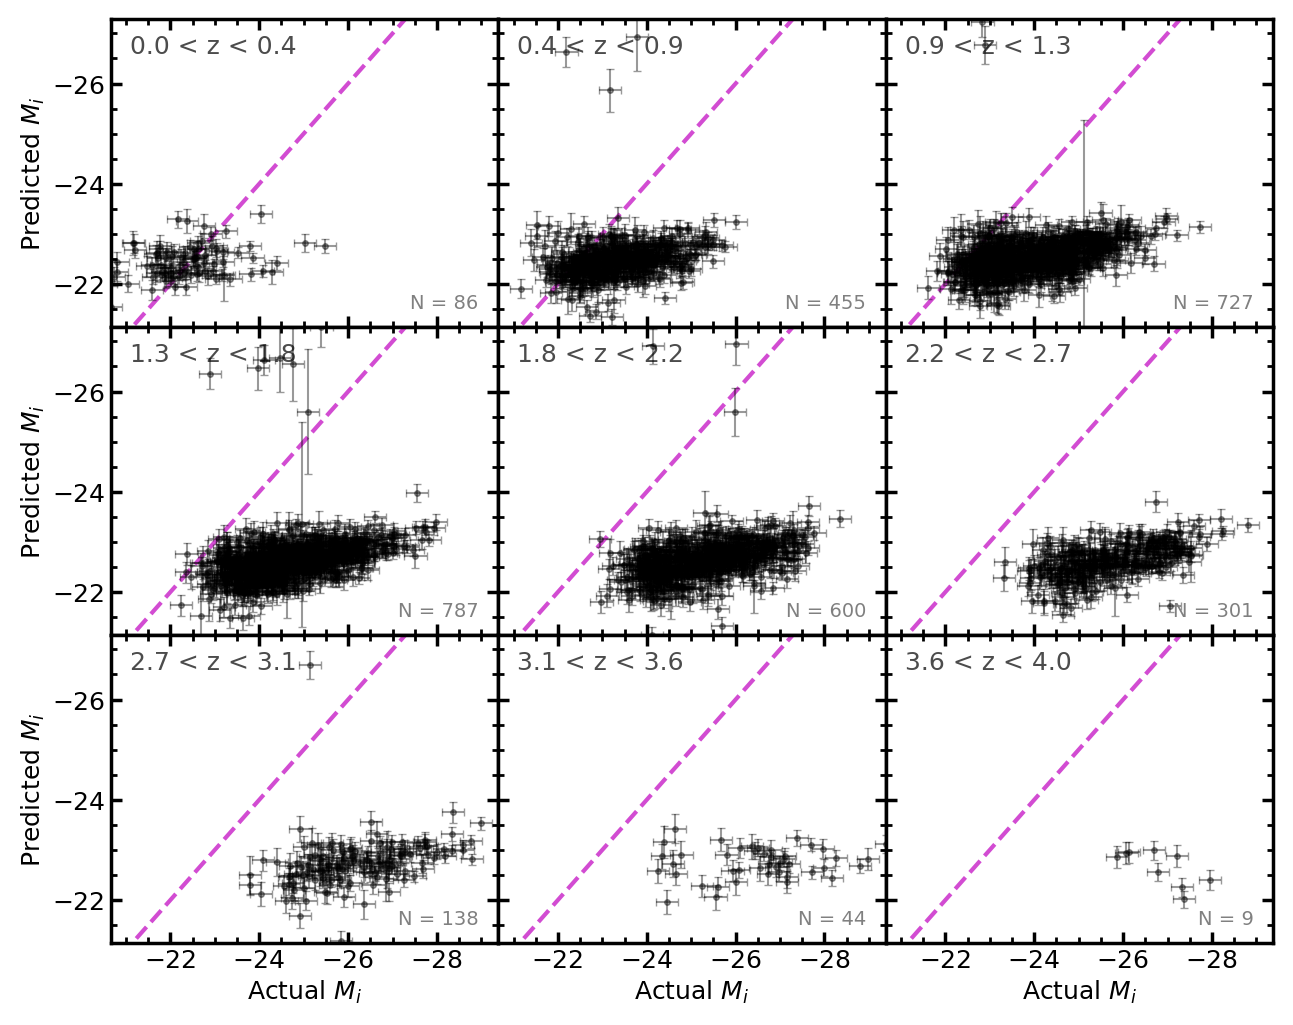

In [7]:
import emcee
import numpy as np
from hubble_plotting import plot_predicted_vs_actual_Mi

cosmo_model = 'Flatw0waCDM'

samples_emcee = np.load("plots/hubble/run_w1000s500/samples_emcee_Flatw0waCDM_agn.npy")
plot_predicted_vs_actual_Mi(0, df_agn, cosmo_model=cosmo_model, show=True, flat_samples=samples_emcee)


Generating corner plot: 100%|██████████| 4/4 [01:59<00:00, 29.82s/it]


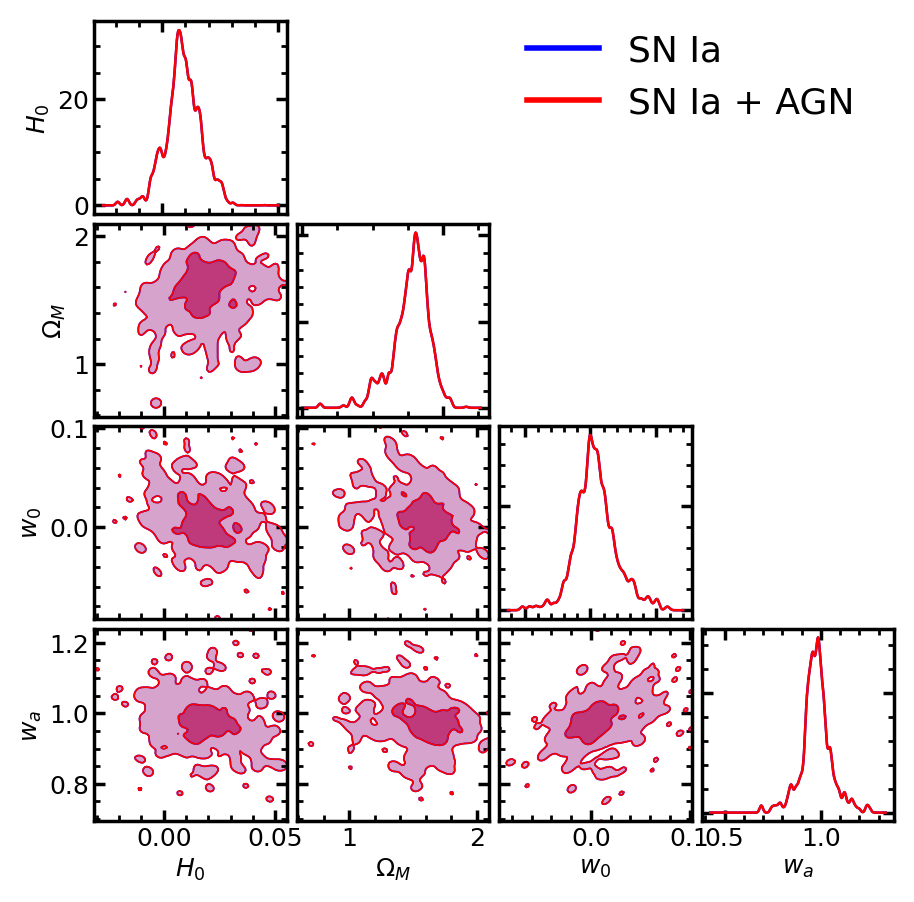

In [ ]:
from hubble_plotting import plot_cosmo_corner

samples_agn = np.load("plots/hubble/run_w1000s500/samples_emcee_Flatw0waCDM_agn.npy")
plot_cosmo_corner(None, None, cosmo_model=cosmo_model, show=True, sna_data=samples_agn, agn_data=samples_agn)


In [25]:
from hubble_plotting import plot_hubble

residuals, mu_pred_std = plot_hubble(None, df_agn, df_pantheon, cosmo_model=cosmo_model, show=True, completeness=True, show_uncorrected=True, flat_samples=samples_emcee[::10, :])

Applying completeness correction in hubble diagram...


KeyError: 'apparent_mag_i_corr'